# **Feature Selection Possible?**

This notebook aims to determine positive influence of feature selection (based on f-statistics) on predictive power of models.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler

In [ ]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **Regression approach**

In [ ]:
performance_trackerENPH = {}

for variable_count in range(50, 541, 10):
    for ticker in ["ENPH"]:
        # Bounded training-validation set
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerENPH[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 3.663656134870187
60 3.6576578581119454
70 3.6285861223721887
80 3.6161153327735853
90 3.605015130778479
100 3.611253854500598
110 3.613748913120233
120 3.5952061536157363
130 3.6027180482620977
140 3.6004484100130845
150 3.593686244569086
160 3.58698690664876
170 3.5782294000854296
180 3.581590043151537
190 3.579832373446519
200 3.5779146011356286
210 3.5730896084630435
220 3.577526490258485
230 3.5742717819589207
240 3.570346879710643
250 3.570346879710643
260 3.5721995701185265
270 3.571249932546864
280 3.5682013435276936
290 3.566348653119809
300 3.56572971408339
310 3.56572971408339
320 3.56572971408339
330 3.56572971408339
340 3.56572971408339
350 3.56572971408339
360 3.5634527056232685
370 3.5634527056232685
380 3.5634527056232685
390 3.5634527056232685
400 3.5634527056232685
410 3.564317465230402
420 3.564317465230402
430 3.564317465230402
440 3.564317465230402
450 3.564317465230402
460 3.564317465230402
470 3.564317465230402
480 3.564317465230402
490 3.564317465230402
500 3

Text(0, 0.5, 'MAPE')

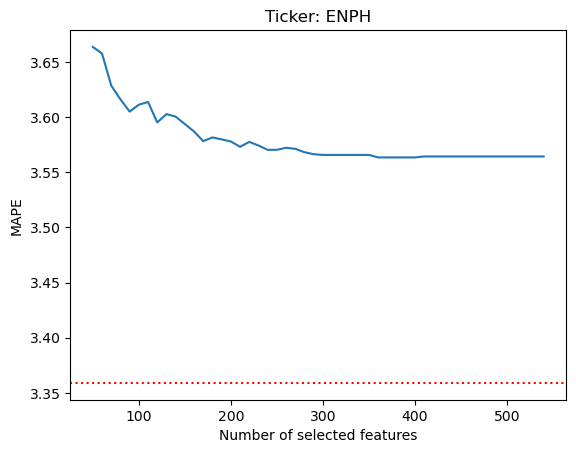

In [ ]:
plt.plot(performance_trackerENPH.keys(), performance_trackerENPH.values())
plt.title("Ticker: ENPH")
#plt.axhline(3.35899166971026, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [ ]:
performance_trackerROP = {}

for variable_count in range(50, 541, 10):
    for ticker in ["ROP"]:
        # Bounded training-validation set
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerROP[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 1.1718873743359355
60 1.1740625891283305
70 1.1637381593327008
80 1.1679071332507418
90 1.1715015743330868
100 1.1651816176957017
110 1.1672913539974912
120 1.1566748335319657
130 1.1521185364269455
140 1.1485055034343816
150 1.146836764708933
160 1.1448037510404883
170 1.1409742955742412
180 1.140663618546732
190 1.1389671414498237
200 1.1406911723064463
210 1.1387623468447552
220 1.139814029310145
230 1.1380646389287377
240 1.1379957005881531
250 1.1381181648674084
260 1.1381054093877179
270 1.137960560098693
280 1.1366651097555749
290 1.1362312079770445
300 1.136442515812259
310 1.136442515812259
320 1.1367427252174795
330 1.1367427252174795
340 1.1365314173822652
350 1.1365314173822652
360 1.1365314173822652
370 1.1365314173822652
380 1.1367427252174795
390 1.1367427252174795
400 1.1365314173822652
410 1.1367427252174795
420 1.1367427252174795
430 1.1367427252174795
440 1.1367427252174795
450 1.1367427252174795
460 1.1367427252174795
470 1.1367427252174795
480 1.1367427252174795

Text(0, 0.5, 'MAPE')

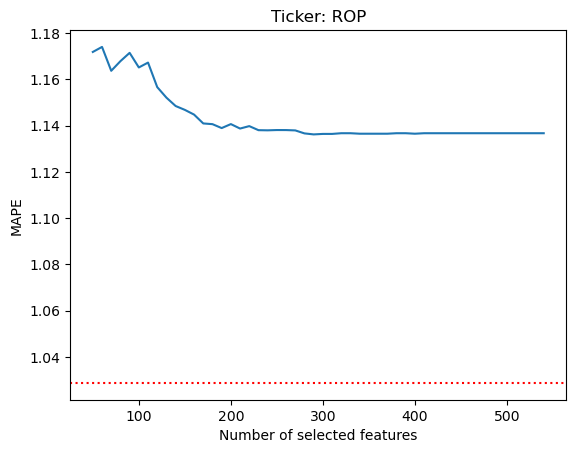

In [ ]:
plt.plot(performance_trackerROP.keys(), performance_trackerROP.values())

plt.title("Ticker: ROP")
#plt.axhline(1.0287623850054408, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [ ]:
performance_trackerVRSN = {}

for variable_count in range(50, 541, 10):
    for ticker in ["VRSN"]:
        # Bounded training-validation set
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerVRSN[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 1.275571072428452
60 1.2765575887810925
70 1.2750891059181908
80 1.2746681249029093
90 1.273886184746935
100 1.2689870819984779
110 1.2678478334751706
120 1.2612848950114586
130 1.2635606156144867
140 1.2642452284719643
150 1.2591449454783723
160 1.2570761127812873
170 1.2564630728989628
180 1.2544348569387782
190 1.2517349659164245
200 1.250185478735351
210 1.2519854558296186
220 1.249967010748073
230 1.2492661597049153
240 1.2492661597049153
250 1.249592861583979
260 1.2498159204443384
270 1.2498159204443384
280 1.2498159204443384
290 1.2523398152753598
300 1.249592861583979
310 1.2498753716224267
320 1.2489645173796267
330 1.251488412210648
340 1.251488412210648
350 1.251488412210648
360 1.251488412210648
370 1.251488412210648
380 1.251488412210648
390 1.251488412210648
400 1.251488412210648
410 1.2489645173796267
420 1.2489645173796267
430 1.2489645173796267
440 1.2489645173796267
450 1.2489645173796267
460 1.2489645173796267
470 1.2489645173796267
480 1.2489645173796267
490 1.2

Text(0, 0.5, 'MAPE')

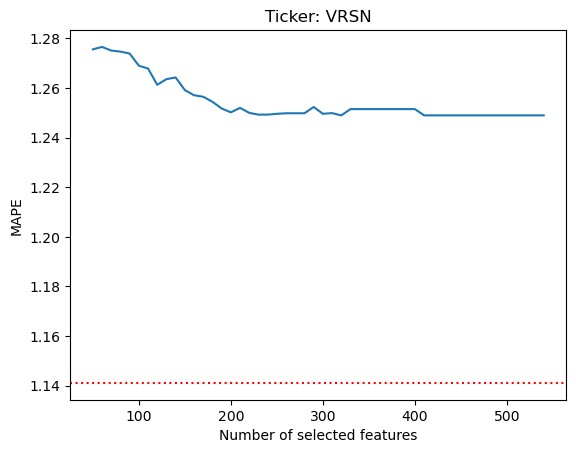

In [ ]:
plt.plot(performance_trackerVRSN.keys(), performance_trackerVRSN.values())
plt.title("Ticker: VRSN")
#plt.axhline(1.1411015691435789, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [ ]:
performance_trackerCSCO = {}

for variable_count in range(50, 541, 10):
    for ticker in ["CSCO"]:
        # Bounded training-validation set
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=mutual_info_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerCSCO[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))
# 1.1650666341016036

Text(0, 0.5, 'MAPE')

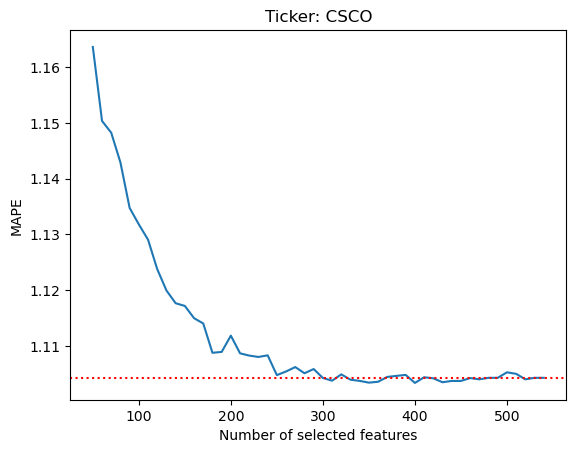

In [ ]:
plt.plot(performance_trackerCSCO.keys(), performance_trackerCSCO.values())
plt.title("Ticker: CSCO")
#plt.axhline(1.1042521527165736, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In <code>$CSCO</code> there is possible positive influence on the predictive modelling; however, negligible, trade-off with time complexity very big.

In [ ]:
performance_trackerCSCO2 = {}

for variable_count in range(50, 541, 10):
    for ticker in ["CSCO"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerCSCO2[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 1.1650666341016036
60 1.1498188157321454
70 1.1438347520225014
80 1.1306172240260228
90 1.1198160218948492
100 1.11908888987742
110 1.115189525629292
120 1.1151185908545778
130 1.1182769651502107
140 1.1173464450841735
150 1.1175661150561016
160 1.1155159019670726
170 1.1119178940683618
180 1.112124908892753
190 1.1094918198959707
200 1.1084749504811848
210 1.1081967053265773
220 1.1082351125224732
230 1.106911338604687
240 1.1074856209663606
250 1.1062105291058655
260 1.106180508764672
270 1.1059582884826384
280 1.104376669121339
290 1.105893419986157
300 1.104506900707111
310 1.1045258413107544
320 1.1060425921755725
330 1.1045258413107544
340 1.1044801195949245
350 1.104750772993935
360 1.106267523858753
370 1.106267523858753
380 1.106267523858753
390 1.106267523858753
400 1.106267523858753
410 1.104750772993935
420 1.1042521527165736
430 1.1042521527165736
440 1.1042521527165736
450 1.1042521527165736
460 1.1042521527165736
470 1.1042521527165736
480 1.1042521527165736
490 1.104

Possible test of <code>score_func</code> found no improvement in any terms. Declined for further analysis

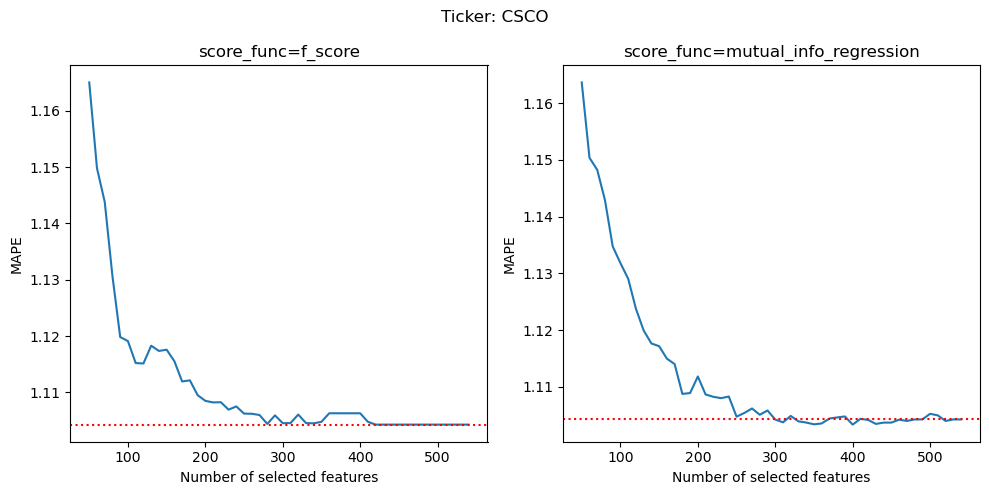

In [ ]:
fig, ax = plt.subplots(1, 2)
fig.set_figheight(5)
fig.set_figwidth(10)

fig.suptitle("Ticker: CSCO")

ax[0].plot(performance_trackerCSCO2.keys(), performance_trackerCSCO2.values())
ax[0].axhline(1.1042521527165736, linestyle="dotted", c="red")

ax[0].set_xlabel("Number of selected features")
ax[0].set_ylabel("MAPE")
ax[1].set_title("score_func=mutual_info_regression")

ax[1].plot(performance_trackerCSCO.keys(), performance_trackerCSCO.values())
ax[1].axhline(1.1042521527165736, linestyle="dotted", c="red")

ax[1].set_xlabel("Number of selected features")
ax[1].set_ylabel("MAPE")
ax[0].set_title("score_func=f_score")

plt.tight_layout()
plt.show()